In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

In [20]:
arquivo_enviado = files.upload()

Saving dados_bootstrap.xlsx to dados_bootstrap (2).xlsx


In [21]:
nome_arquivo = next(iter(arquivo_enviado))

df = pd.read_excel(nome_arquivo)

print("Dimensão da planilha:", df.shape)
display(df)

Dimensão da planilha: (9, 20)


,Q_Lmin,U_ms,DP_01,DP_02,DP_03,DP_04,DP_05,DP_06,DP_07,DP_08,DP_09,DP_10,DP_11,DP_12,DP_13,DP_14,DP_15,DP_16,DP_17,DP_18
0,60,0.199,70,70,70,70,70,70,85,90,75,55,65,75,50,50,80,75,75,75
1,80,0.265,75,75,75,85,75,85,95,97,80,70,70,85,60,60,75,75,80,80
2,100,0.332,80,80,80,90,80,90,100,100,90,75,75,85,75,60,90,80,90,85
3,120,0.398,85,85,85,90,90,95,105,105,93,85,80,88,70,70,95,85,85,90
4,140,0.464,90,90,90,90,90,95,110,110,110,105,100,90,75,70,95,85,100,95
5,160,0.531,100,100,110,100,100,110,115,120,110,110,100,100,75,75,100,100,100,100
6,180,0.597,110,110,125,110,110,130,120,120,110,110,110,110,120,80,110,115,115,115
7,200,0.663,110,110,135,110,110,130,120,120,120,120,120,120,125,120,120,120,120,120
8,220,0.729,110,110,135,135,135,130,120,120,120,120,120,120,120,120,120,120,120,120


In [22]:
Q = df["Q_Lmin"].to_numpy(dtype=float)
U = df["U_ms"].to_numpy(dtype=float)

colunas_dp = [f"DP_{i:02d}" for i in range(1, 19)]
DP = df[colunas_dp].to_numpy(dtype=float)

print("Q:", Q)
print("U:", U)
print("Formato da matriz de ΔP:", DP.shape)

Q: [ 60.  80. 100. 120. 140. 160. 180. 200. 220.]
U: [0.199 0.265 0.332 0.398 0.464 0.531 0.597 0.663 0.729]
Formato da matriz de ΔP: (9, 18)


In [23]:
medianas_observadas = np.median(DP, axis=1)

verificacao = pd.DataFrame({
    "Q_Lmin": Q,
    "U_ms": U,
    "Mediana_DP": medianas_observadas
})

display(verificacao)

,Q_Lmin,U_ms,Mediana_DP
0,60.0,0.199,70.0
1,80.0,0.265,75.0
2,100.0,0.332,82.5
3,120.0,0.398,86.5
4,140.0,0.464,92.5
5,160.0,0.531,100.0
6,180.0,0.597,110.0
7,200.0,0.663,120.0
8,220.0,0.729,120.0


In [24]:
def calcular_UdeltaP95(U, dp_mediana, n_pontos_patamar=2):
    """
    Calcula UdeltaP,95 como a velocidade na qual ΔP atinge
    95% do patamar médio dos últimos pontos.
    """

    patamar = np.mean(dp_mediana[-n_pontos_patamar:])
    dp_95 = 0.95 * patamar

    # Procura o primeiro intervalo que contém dp_95
    for i in range(len(U) - 1):
        y1 = dp_mediana[i]
        y2 = dp_mediana[i + 1]

        if (y1 <= dp_95 <= y2) or (y2 <= dp_95 <= y1):

            if y2 == y1:
                return U[i], patamar, dp_95

            UdeltaP95 = U[i] + (
                (dp_95 - y1) *
                (U[i + 1] - U[i]) /
                (y2 - y1)
            )

            return UdeltaP95, patamar, dp_95

    return np.nan, patamar, dp_95

In [25]:
def calcular_umf_intersecao(
    U,
    dp_mediana,
    k_inicial=7,
    n_pontos_patamar=2
):
    """
    Ajusta uma reta aos k primeiros pontos e calcula
    sua interseção com o patamar médio dos últimos pontos.
    """

    U_inicial = U[:k_inicial]
    DP_inicial = dp_mediana[:k_inicial]

    coef_angular, intercepto = np.polyfit(
        U_inicial,
        DP_inicial,
        1
    )

    patamar = np.mean(dp_mediana[-n_pontos_patamar:])

    if coef_angular == 0:
        return np.nan, coef_angular, intercepto, patamar

    umf_int = (patamar - intercepto) / coef_angular

    return umf_int, coef_angular, intercepto, patamar

In [26]:
UdeltaP95_pontual, patamar_pontual, dp95_pontual = calcular_UdeltaP95(
    U,
    medianas_observadas
)

umfint_pontual, a_pontual, b_pontual, patamar_int = (
    calcular_umf_intersecao(
        U,
        medianas_observadas
    )
)

print(f"Patamar: {patamar_pontual:.3f} mmH2O")
print(f"95% do patamar: {dp95_pontual:.3f} mmH2O")
print(f"UdeltaP,95: {UdeltaP95_pontual:.6f} m/s")
print(f"Umf,int: {umfint_pontual:.6f} m/s")
print(f"Reta inicial: ΔP = {a_pontual:.6f} U + {b_pontual:.6f}")

Patamar: 120.000 mmH2O
95% do patamar: 114.000 mmH2O
UdeltaP,95: 0.623400 m/s
Umf,int: 0.727555 m/s
Reta inicial: ΔP = 96.883821 U + 49.511668


In [27]:
B = 5000
n = DP.shape[1]

# Semente fixa para garantir reprodutibilidade computacional
rng = np.random.default_rng(2026)

vetor_UdeltaP95 = []
vetor_umfint = []

for b in range(B):

    medianas_bootstrap = np.empty(len(U))

    for i in range(len(U)):

        amostra_bootstrap = rng.choice(
            DP[i, :],
            size=n,
            replace=True
        )

        medianas_bootstrap[i] = np.median(
            amostra_bootstrap
        )

    UdeltaP95_b, _, _ = calcular_UdeltaP95(
        U,
        medianas_bootstrap,
        n_pontos_patamar=2
    )

    umfint_b, _, _, _ = calcular_umf_intersecao(
        U,
        medianas_bootstrap,
        k_inicial=7,
        n_pontos_patamar=2
    )

    if np.isfinite(UdeltaP95_b):
        vetor_UdeltaP95.append(UdeltaP95_b)

    if np.isfinite(umfint_b):
        vetor_umfint.append(umfint_b)

vetor_UdeltaP95 = np.asarray(vetor_UdeltaP95)
vetor_umfint = np.asarray(vetor_umfint)

print("Reamostragens válidas para UdeltaP,95:", len(vetor_UdeltaP95))
print("Reamostragens válidas para Umf,int:", len(vetor_umfint))

Reamostragens válidas para UdeltaP,95: 5000
Reamostragens válidas para Umf,int: 5000


In [28]:
ic_UdeltaP95 = np.percentile(
    vetor_UdeltaP95,
    [2.5, 97.5]
)

ic_umfint = np.percentile(
    vetor_umfint,
    [2.5, 97.5]
)

print("RESULTADOS BOOTSTRAP")
print("-" * 50)

print(
    f"UdeltaP,95 pontual = {UdeltaP95_pontual:.3f} m/s"
)

print(
    f"IC95% UdeltaP,95 = "
    f"{ic_UdeltaP95[0]:.3f} – "
    f"{ic_UdeltaP95[1]:.3f} m/s"
)

print()

print(
    f"Umf,int pontual = {umfint_pontual:.3f} m/s"
)

print(
    f"IC95% Umf,int = "
    f"{ic_umfint[0]:.3f} – "
    f"{ic_umfint[1]:.3f} m/s"
)

RESULTADOS BOOTSTRAP
--------------------------------------------------
UdeltaP,95 pontual = 0.623 m/s
IC95% UdeltaP,95 = 0.584 – 0.623 m/s

Umf,int pontual = 0.728 m/s
IC95% Umf,int = 0.670 – 0.765 m/s


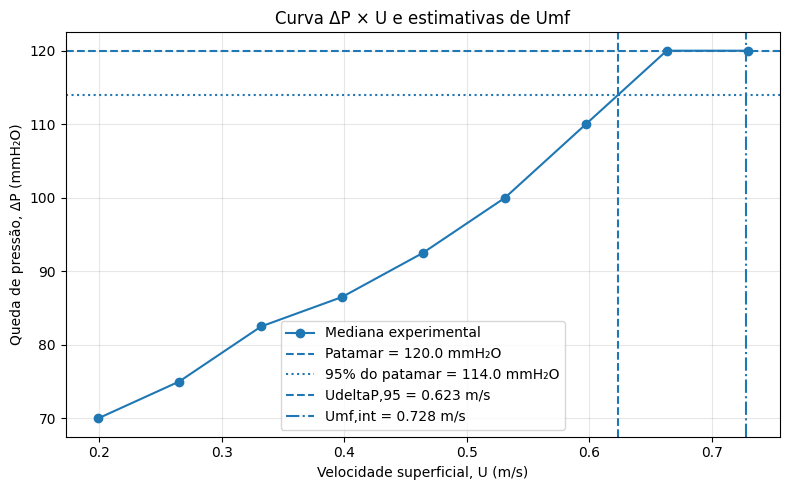

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    U,
    medianas_observadas,
    marker="o",
    label="Mediana experimental"
)

plt.axhline(
    patamar_pontual,
    linestyle="--",
    label=f"Patamar = {patamar_pontual:.1f} mmH₂O"
)

plt.axhline(
    dp95_pontual,
    linestyle=":",
    label=f"95% do patamar = {dp95_pontual:.1f} mmH₂O"
)

plt.axvline(
    UdeltaP95_pontual,
    linestyle="--",
    label=f"UdeltaP,95 = {UdeltaP95_pontual:.3f} m/s"
)

plt.axvline(
    umfint_pontual,
    linestyle="-.",
    label=f"Umf,int = {umfint_pontual:.3f} m/s"
)

plt.xlabel("Velocidade superficial, U (m/s)")
plt.ylabel("Queda de pressão, ΔP (mmH₂O)")
plt.title("Curva ΔP × U e estimativas de Umf")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "curva_DP_U_Umf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

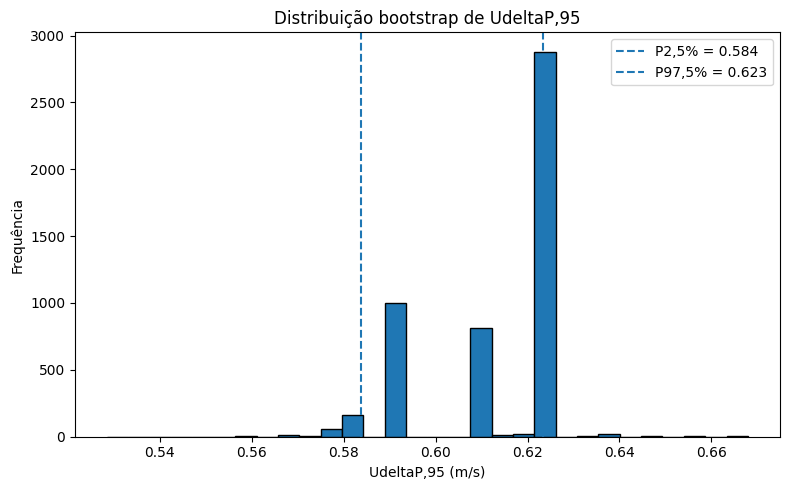

In [30]:
plt.figure(figsize=(8, 5))

plt.hist(
    vetor_UdeltaP95,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    ic_UdeltaP95[0],
    linestyle="--",
    label=f"P2,5% = {ic_UdeltaP95[0]:.3f}"
)

plt.axvline(
    ic_UdeltaP95[1],
    linestyle="--",
    label=f"P97,5% = {ic_UdeltaP95[1]:.3f}"
)

plt.xlabel("UdeltaP,95 (m/s)")
plt.ylabel("Frequência")
plt.title("Distribuição bootstrap de UdeltaP,95")
plt.legend()
plt.tight_layout()

plt.savefig(
    "bootstrap_UdeltaP95.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

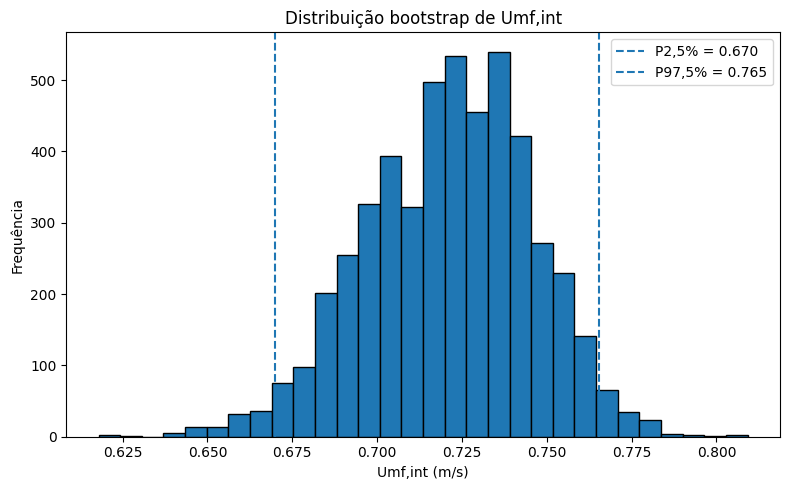

In [31]:
plt.figure(figsize=(8, 5))

plt.hist(
    vetor_umfint,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    ic_umfint[0],
    linestyle="--",
    label=f"P2,5% = {ic_umfint[0]:.3f}"
)

plt.axvline(
    ic_umfint[1],
    linestyle="--",
    label=f"P97,5% = {ic_umfint[1]:.3f}"
)

plt.xlabel("Umf,int (m/s)")
plt.ylabel("Frequência")
plt.title("Distribuição bootstrap de Umf,int")
plt.legend()
plt.tight_layout()

plt.savefig(
    "bootstrap_Umfint.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
resultado_resumo = pd.DataFrame({
    "Estimador": ["UdeltaP,95", "Umf,int"],
    "Estimativa_pontual_m_s": [
        UdeltaP95_pontual,
        umfint_pontual
    ],
    "IC95_inferior_m_s": [
        ic_UdeltaP95[0],
        ic_umfint[0]
    ],
    "IC95_superior_m_s": [
        ic_UdeltaP95[1],
        ic_umfint[1]
    ],
    "B": [B, B],
    "Trecho_inicial_k": [
        "Não aplicável",
        7
    ],
    "Pontos_patamar": [2, 2]
})

distribuicoes = pd.DataFrame({
    "UdeltaP95_bootstrap": pd.Series(vetor_UdeltaP95),
    "Umfint_bootstrap": pd.Series(vetor_umfint)
})

with pd.ExcelWriter(
    "resultados_bootstrap_Umf.xlsx",
    engine="openpyxl"
) as writer:

    resultado_resumo.to_excel(
        writer,
        sheet_name="Resumo",
        index=False
    )

    verificacao.to_excel(
        writer,
        sheet_name="Medianas",
        index=False
    )

    distribuicoes.to_excel(
        writer,
        sheet_name="Distribuicoes",
        index=False
    )

display(resultado_resumo)

,Estimador,Estimativa_pontual_m_s,IC95_inferior_m_s,IC95_superior_m_s,B,Trecho_inicial_k,Pontos_patamar
0,"UdeltaP,95",0.623400,0.583800,0.623400,5000,Não aplicável,2
1,"Umf,int",0.727555,0.669941,0.765246,5000,7,2


In [33]:
files.download("resultados_bootstrap_Umf.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
files.download("curva_DP_U_Umf.png")
files.download("bootstrap_UdeltaP95.png")
files.download("bootstrap_Umfint.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
import sys
import platform
import numpy as np
import pandas as pd
import matplotlib
from datetime import datetime

print("Python:", platform.python_version())
print("Implementação:", platform.python_implementation())
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Data da execução:", datetime.now().strftime("%d/%m/%Y %H:%M"))
print("Descrição completa do Python:", sys.version)

Python: 3.13.15
Implementação: CPython
NumPy: 2.1.3
pandas: 2.2.3
Matplotlib: 3.10.0
Data da execução: 23/09/2026 20:18
Descrição completa do Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


In [36]:
import openpyxl
print("openpyxl:", openpyxl.__version__)

openpyxl: 3.1.5
